In [4]:
#Packages
#for scientific computation
import numpy as np

#for plotting graphs
%matplotlib widget
import matplotlib.pyplot as plt

#for data mining
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#for machine learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu, linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

#for error control
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from public_tests_a1 import *

tf.keras.backend.set_floatx('float64')
from assignment_utils import *

tf.autograph.set_verbosity(0)


In [ ]:
#1. EVALUATING A LEARNING ALGORITHM (POLYNOMIAL REGRESSION)
#splitting the dataset into learning and test sets
#generate some data
X, y, x_ideal, y_ideal = gen_data(18, 2, 0.7)  #generate 18 example data points
print('X.shape', X.shape, 'y.shape', y.shape)

#split the data using sklearn routine
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
print(f'X_train.shape', X_train.shape, f'y_train.shape', y_train.shape) 
print(f'X_test.shape', X_test.shape, f'y_test.shape', y_test.shape)

X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


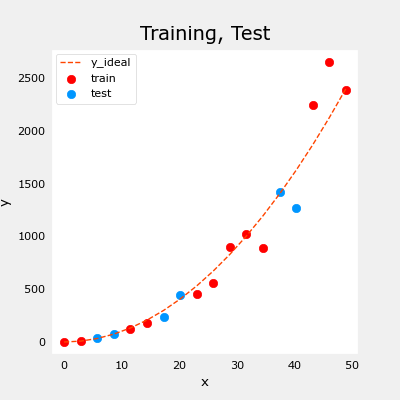

In [18]:
#plot the train, and test sets
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, '--', color='orangered', label='y_ideal', lw=1)
ax.set_title('Training, Test', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')

ax.scatter(X_train, y_train, color='red', label='train')
ax.scatter(X_test, y_test, color=dlc['dlblue'], label='test')
ax.legend(loc='upper left')
plt.show()

In [19]:
#error calculation for model evaluation(linear regression)
#a function to evaluate the error on a dataset for a linear regression model
# 𝐽test(𝐰,𝑏)=1/2𝑚test∑𝑖=0𝑚test−1(𝑓𝐰,𝑏(𝐱(𝑖)test)−𝑦(𝑖)test)^2
def eval_mse(y, yhat):
    ''' 
    Calculate the mean squared error on a dataset

    Args: 
     y : (ndarray shape (m,) or (m, 1)) target value of each example
     yhat :(ndarray shape (m,) or (m,1)) predicted vale of each example

    Returns:
     err : (scalar)

    '''
    m = len(y)
    err = 0.0
    for i in range(m):
        err_i = ( (yhat[i] - y[i])**2)
        err += err_i
    err = err / (2*m)
    return(err)


In [20]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)


0.0050000000000000305

In [21]:
#unit test
test_eval_mse(eval_mse)

 All tests passed.


In [22]:
#Compare performance on training and test sets

#create a model in sklearn, train on training data
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train)

#predict on training data, find training error
yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)

#predict on test data, find error
yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

In [23]:
#print to compare the training and test errors
print(f'Training error {err_train:0.2f}, Test error {err_test:0.2f}')

Training error 58.01, Test error 171215.01


In [ ]:
#observation: Training error is lower than the test error
#This model is overfitting, has high variance, and generalizes poorly(does not fit well on new data)

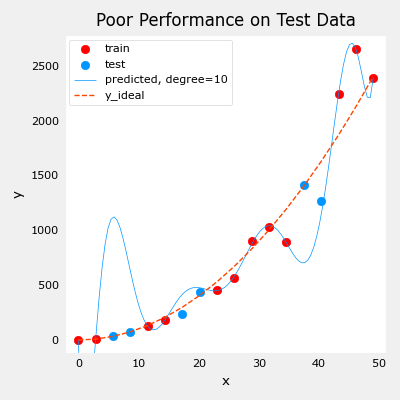

In [24]:
#plot to visualize
x = np.linspace(0, int(X.max()), 100)
y_pred = lmodel.predict(x).reshape(-1,1)

plt_train_test(X_train, y_train, X_test, y_test, x, y_pred, x_ideal, y_ideal, degree)

In [27]:
#generating 3 datasets
X, y,x_ideal, y_ideal = gen_data(40, 5, 0.7)
print('X.shape', X.shape, 'y.shape', y.shape)

#split the data using sklearn routine
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, random_state=1)
print('X_train shape', X_train.shape, 'y_train.shape', y_train.shape)
print('X_cv.shape', X_cv.shape, 'y_cv.shape', y_cv.shape)
print('X_test.shape', X_test.shape, 'y_test.shape', y_test.shape)


X.shape (40,) y.shape (40,)
X_train shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


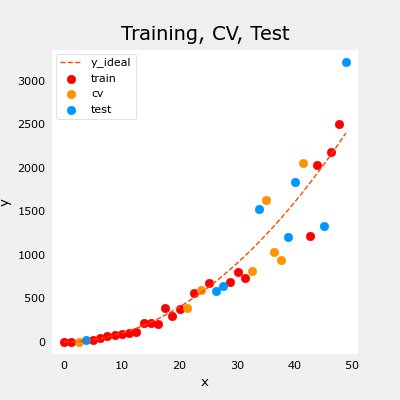

In [32]:
#2. BIAS AND VARIANCE
#plot the train, cv, and test plots
fig, ax = plt.subplots(1,1, figsize=(4,4))
ax.plot(x_ideal, y_ideal, '--', color='orangered', label='y_ideal', lw=1)
ax.set_title('Training, CV, Test', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')

ax.scatter(X_train, y_train, color='red', label='train')
ax.scatter(X_cv, y_cv, color = dlc['dlorange'], label='cv')
ax.scatter(X_test, y_test, color = dlc['dlblue'], label='test')
ax.legend(loc='upper left')
plt.show()

In [35]:
#train the model repeatedly, increasing the polynomial degree in each iteration
max_degree = 9
err_train = np.zeros(max_degree)
err_cv = np.zeros(max_degree)
x = np.linspace(0, int(X.max()), 100) 
y_pred = np.zeros((100, max_degree)) #columns are lines to plot

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)

    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)

    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv,yhat)
    
    y_pred[:, degree] = lmodel.predict(x)

optimal_degree = np.argmin(err_cv)+1

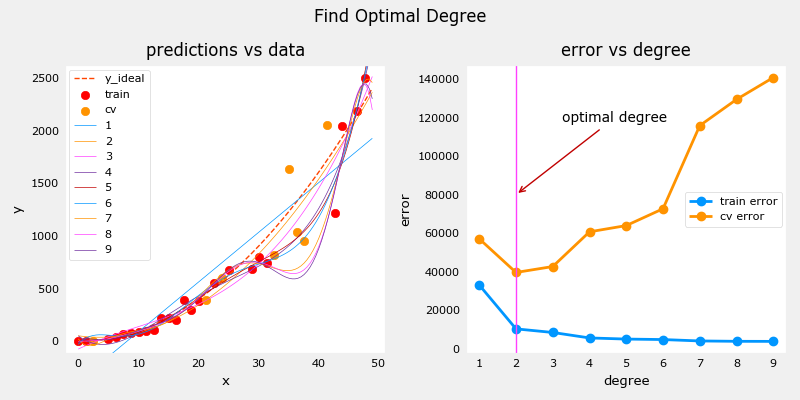

In [36]:
#plot tovisualize
plt.close('all')
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal,
err_train, err_cv, optimal_degree, max_degree)

In [ ]:
#Observation
#Fig 1 (left side)
# The degree of polynomial defines whether the model is underfiting or overfitting
# degree 1 is underfitting(straight line), degree 9 is overfiting(curvy fit)
#Fig 2 (right side)
# the training error decreases as the degree increases
# the cv error decreases at the beggining but increases with the degree of polynomial

In [44]:
#Tuning regularization to reduce overfitting(high variance)
#high degree polynomial
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)
err_cv = np.zeros(num_steps)
x = np.linspace(0, int(X.max()), 100)
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_ = lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)

    y_pred[:,i] = lmodel.predict(x)

optimal_reg_idx = np.argmin(err_cv)

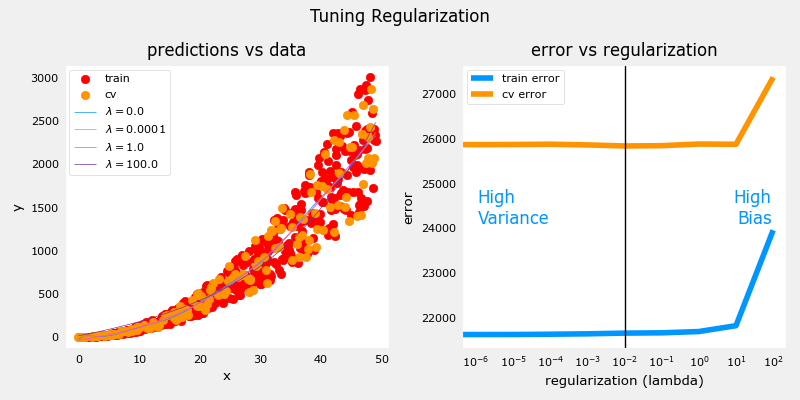

In [45]:
#plot to visualize
plt.close('all')
plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

In [ ]:
#observation 
# the model moves from high variance(overfiting) to high bias(underfiting) as the regularization increases

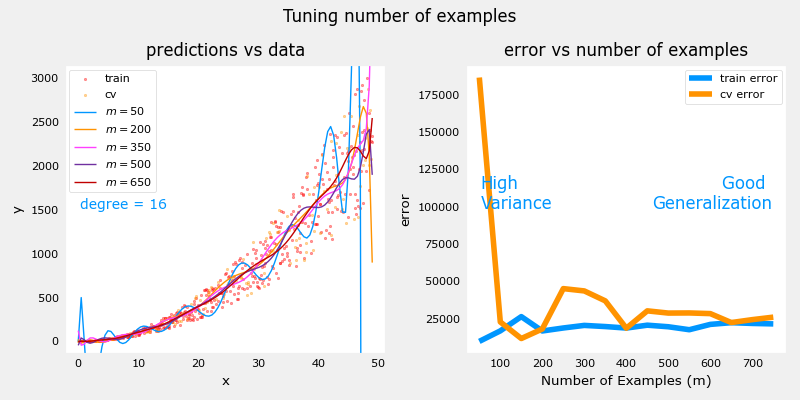

In [ ]:
#increasing training size(m) - getting more data
X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree = tune_m()
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

In [ ]:
#observation:
# addinng more data examples improves performance - better generalization

In [46]:
#3. EVALUATING NEURAL NETWORK
#data set
#Generate and split the dataset(train, CV, test sets)
X, y, centers, classes, std = gen_blobs()

#split the data. Large CV population for demonstration
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.20, random_state=1)
print('X_train.shape', X_train.shape, 'X_cv.shape', X_cv.shape, 'X_test.shape', X_test.shape)

X_train.shape (400, 2) X_cv.shape (320, 2) X_test.shape (80, 2)


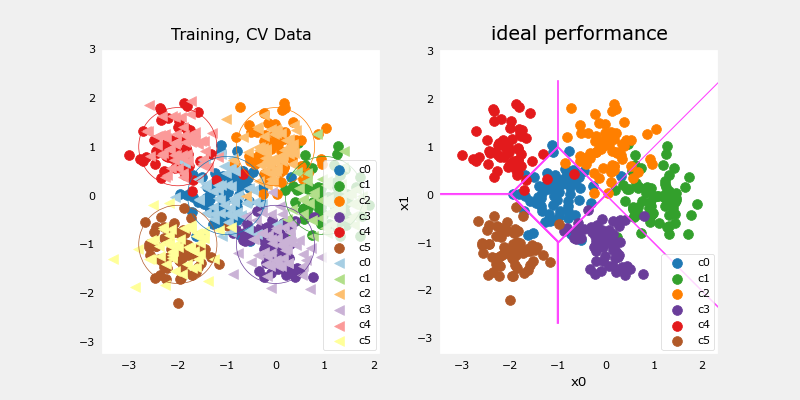

In [47]:
#plot
plt_train_eq_dist(X_train, y_train, classes, X_cv, y_cv, centers, std)

In [ ]:
#Observation

#training points (dots) and cross-validation points (triangles)
# Some points fall in ambiguous locations where either cluster might consider them members


In [48]:
#evaluating categorical data
# 𝐽𝑐𝑣=1/𝑚∑𝑖=0 upto 𝑚−1 {1,0,if 𝑦̂ (𝑖)≠𝑦(𝑖)otherwise
def eval_cat_err(y, yhat):
    ''' 
    Calculates the categorization error

    Args:
     y : (ndarray shape (m,) or (m,1) target value of each example)
     yhat : (ndarray shape (m,) or (m,1) predicted value of each example)

    Returns:
     cerr : (scalar)
    '''
    m = len(y)
    incorrect = 0
    for i in range(m):
        if yhat[i] != y[i]:
            incorrect += 1
    cerr = incorrect / m
    return(cerr)

In [49]:
y_hat = np.array([1, 2,0])
y_tmp = np.array([1, 2, 3])
print(f'categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333')

y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f'categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250')

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250


In [50]:
#unit test
test_eval_cat_err(eval_cat_err)

 All tests passed.


In [ ]:
#4. MODEL COMPLEXITY
''' 
compose a three-layer model:

Dense layer with 120 units, relu activation
Dense layer with 40 units, relu activation
Dense layer with 6 units and a linear activation (not softmax)
Compile using - 
 -loss with SparseCategoricalCrossentropy, remember to use from_logits=True
 -Adam optimizer with learning rate of 0.01.
'''

In [51]:
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.random.set_seed(1234)
model= Sequential([
    Dense(120, activation='relu', name='L1'),
    Dense(40, activation='relu', name='L2'),
    Dense(6, activation='linear', name='L3'),
], name='Complex'

) 

model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01), 
)

In [52]:
#unit test
model.fit(
    X_train, y_train,
    epochs=1000
)

Epoch 1/1000
13/13 [==============================] - 3s 6ms/step - loss: 1.1168
Epoch 2/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.4416
Epoch 3/1000
13/13 [==============================] - 0s 1ms/step - loss: 0.3289
Epoch 4/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2786
Epoch 5/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2588
Epoch 6/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2906
Epoch 7/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2546
Epoch 8/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2271
Epoch 9/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2313
Epoch 10/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2056
Epoch 11/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2242
Epoch 12/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2106
Epoch 13/1000
13/13 [====

In [53]:
#unit test
model.summary()
model_test(model, classes, X_train.shape[1])

Model: "Complex"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 120)               360       
                                                                 
 L2 (Dense)                  (None, 40)                4840      
                                                                 
 L3 (Dense)                  (None, 6)                 246       
                                                                 
Total params: 5,446
Trainable params: 5,446
Non-trainable params: 0
_________________________________________________________________
All tests passed!


1082/1082 [==============================] - 2s 1ms/step


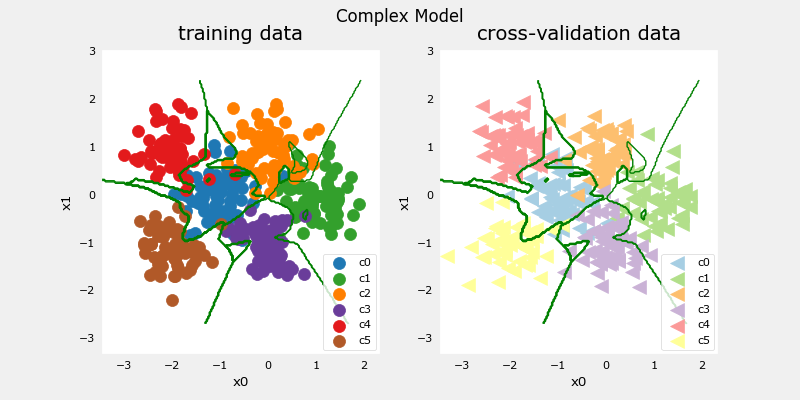

In [55]:
#make a model for plotting routines to call
model_predict = lambda X1: np.argmax(tf.nn.softmax(model.predict(X1)).numpy(), axis=1)
plt_nn(model_predict, X_train, y_train, classes, X_cv, y_cv, suptitle='Complex Model')

In [ ]:
# This model has worked very hard to capture outliers of each category. 
#  As a result, it has miscategorized some of the cross-validation data. 
#  Let's calculate the classification error

In [57]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f'Categorization error, training, complex model: {training_cerr_complex:0.3f}')
print(f'Categorization error, cv, complex model: {cv_cerr_complex:0.3f}')

10/10 [==============================] - 0s 2ms/step
Categorization error, training, complex model: 0.010
Categorization error, cv, complex model: 0.109


In [58]:
#simple model
tf.random.set_seed(1234)
model_s = Sequential([
    Dense(6, activation='relu', name='L1'),
    Dense(6, activation='linear', name='L2')
], name='Simple'
)

model_s.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)

In [59]:
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

model_s.fit(
    X_train, y_train,
    epochs=1000
)


Epoch 1/1000
13/13 [==============================] - 2s 4ms/step - loss: 1.6706
Epoch 2/1000
13/13 [==============================] - 0s 3ms/step - loss: 1.3919
Epoch 3/1000
13/13 [==============================] - 0s 3ms/step - loss: 1.1778
Epoch 4/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.9886
Epoch 5/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.8363
Epoch 6/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.7100
Epoch 7/1000
13/13 [==============================] - 0s 2ms/step - loss: 0.6176
Epoch 8/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.5350
Epoch 9/1000
13/13 [==============================] - 0s 2ms/step - loss: 0.4728
Epoch 10/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.4204
Epoch 11/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.3816
Epoch 12/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.3532
Epoch 13/1000
13/13 [====

In [ ]:
#unit test
model_s.summary()
model_s_test(model_s, classes, X_train.shape[1])

Model: "Simple"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 6)                 18        
                                                                 
 L2 (Dense)                  (None, 6)                 42        
                                                                 
Total params: 60
Trainable params: 60
Non-trainable params: 0
_________________________________________________________________
All tests passed!


1082/1082 [==============================] - 2s 1ms/step


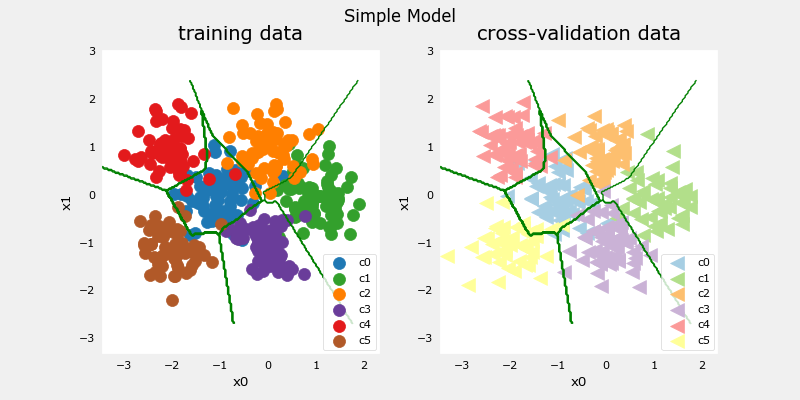

In [69]:
#make a model for plotting routines to call
model_predict_s = lambda X1: np.argmax(tf.nn.softmax(model_s.predict(X1)).numpy(), axis=1)
plt_nn(model_predict_s, X_train, y_train, classes, X_cv, y_cv, suptitle='Simple Model')

In [ ]:
#observation
# This simple model does well
# CAlculate the classification error

In [81]:
training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f'Categorization error, training, simple model, {training_cerr_simple:0.3f},complex model: {training_cerr_complex:0.3f}')
print(f'Categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}')

10/10 [==============================] - 0s 2ms/step
Categorization error, training, simple model, 0.068,complex model: 0.010
Categorization error, cv,       simple model, 0.084, complex model: 0.109


In [ ]:
#observation
# Simple model classification error on training data is higher than on the CV dataset

In [85]:
#5. REGULARIZATION
tf.random.set_seed(1234)
model_r = Sequential([
    Dense(120, activation='relu', kernel_regularizer = tf.keras.regularizers.l2(0.1), name='L1'),
    Dense(40, activation='relu', kernel_regularizer = tf.keras.regularizers.l2(0.1), name='L2'),
    Dense(classes, activation='linear', name='L3')
], name='ComplexRegularized'
)
model_r.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)

In [87]:
#unit test
model_r.fit(
    X_train, y_train,
    epochs=1000
)

Epoch 1/1000
13/13 [==============================] - 1s 5ms/step - loss: 4.3800
Epoch 2/1000
13/13 [==============================] - 0s 4ms/step - loss: 1.5918
Epoch 3/1000
13/13 [==============================] - 0s 3ms/step - loss: 1.2610
Epoch 4/1000
13/13 [==============================] - 0s 3ms/step - loss: 1.0413
Epoch 5/1000
13/13 [==============================] - 0s 2ms/step - loss: 0.9627
Epoch 6/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.9523
Epoch 7/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.9174
Epoch 8/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.8700
Epoch 9/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.8086
Epoch 10/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.7593
Epoch 11/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.7497
Epoch 12/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.7497
Epoch 13/1000
13/13 [====

In [88]:
#unit test
model_r.summary()
model_r_test(model_r, classes, X_train.shape[1])

Model: "ComplexRegularized"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 120)               360       
                                                                 
 L2 (Dense)                  (None, 40)                4840      
                                                                 
 L3 (Dense)                  (None, 6)                 246       
                                                                 
Total params: 5,446
Trainable params: 5,446
Non-trainable params: 0
_________________________________________________________________
ddd
All tests passed!


1082/1082 [==============================] - 2s 2ms/step


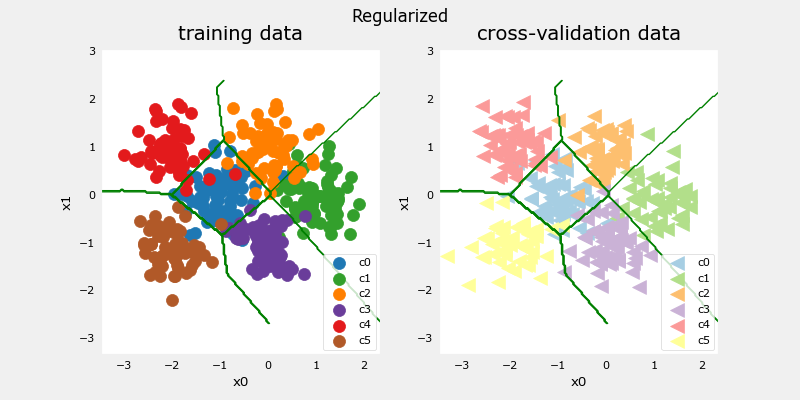

In [89]:
#make a model for plotting routines to call
model_predict_r = lambda X1 : np.argmax(tf.nn.softmax(model_r.predict(X1)).numpy(), axis=1)

plt_nn(model_predict_r, X_train, y_train, classes, X_cv, y_cv, suptitle='Regularized')

In [91]:
#classification error
training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

3/3 [==============================] - 0s 3ms/step
categorization error, training, regularized: 0.075, simple model, 0.068, complex model: 0.010
categorization error, cv,       regularized: 0.075, simple model, 0.084, complex model: 0.109


In [95]:
#6. ITERATE TO FIND OPTIMAL REGULARIZATION VALUE
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models = [None] * len(lambdas)

for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] = Sequential([
        Dense(120, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
        Dense(40, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
        Dense(classes, activation='linear')
    ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer = tf.keras.optimizers.Adam(0.01)
    )
    models[i].fit(
        X_train, y_train,
        epochs=1000
    )
    print(f'Finished lambda = {lambda_}')

Epoch 1/1000
13/13 [==============================] - 1s 3ms/step - loss: 1.0699
Epoch 2/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.4023
Epoch 3/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.3181
Epoch 4/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2997
Epoch 5/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2764
Epoch 6/1000
13/13 [==============================] - 0s 978us/step - loss: 0.2837
Epoch 7/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2441
Epoch 8/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2302
Epoch 9/1000
13/13 [==============================] - 0s 2ms/step - loss: 0.2260
Epoch 10/1000
13/13 [==============================] - 0s 2ms/step - loss: 0.2008
Epoch 11/1000
13/13 [==============================] - 0s 3ms/step - loss: 0.2180
Epoch 12/1000
13/13 [==============================] - 0s 2ms/step - loss: 0.2053
Epoch 13/1000
13/13 [==

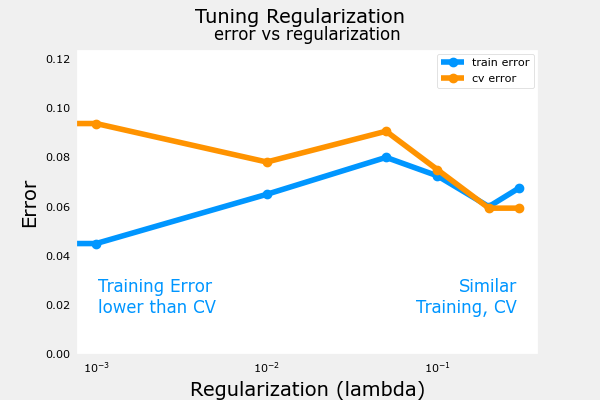

In [96]:
plot_iterate(lambdas, models, X_train, y_train, X_cv, y_cv)

3/3 [==============================] - 0s 2ms/step


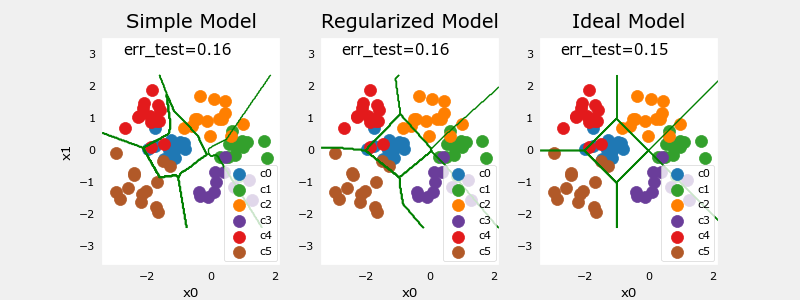

In [97]:
#Test 
plt_compare(X_test, y_test, classes, model_predict_s, model_predict_r, centers)